Project 1

Team: Shuban Iyer(shubani2), Yogi Patel(ypate68), Swarit(swaritt2)

In [2]:
#Currently opening the pickle file using rb and load in order to not edit the data set.
#Need to have the proper imports needed to import from pkle 
#Also want to import numpy in order to help with list functions

import pickle as pkl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
loaded = pkl.load(open('delta_a100_gpu_xid_dataset.pkl', 'rb'))

In [3]:
# Then using loaded, we would like to parse through to find XID errors observed on March 10th, 2024
# XID errors are stored in a list, so can use len to find the number of elements in it
# We also want to find the list of unique XID 
march_10 = loaded['2024-03-10']
print("Number of XID Errors: ", len(march_10)) # this gives us the amount of XID errors for that date

unique_errors = list({errors['XID'] for errors in march_10})
print("Unique XID Errors: ", unique_errors)

Number of XID Errors:  87
Unique XID Errors:  [74, 43, 45, 13, 119, 31]


In [4]:
# creating pandas dataframe to access data
rows = []

# flattening logs down to rows for the dataframe
for date, logs in loaded.items():
    for log in logs:
        entry_row = {
            'Date': date,
            'Datetime': log.get('datetime'),
            'Timestamp': log.get('timestamp'),
            'Node name': log.get('node_name'),
            'Device ID': log.get('device_id'),
            'XID': log.get('XID'),
            'Tag': log.get('Tag')
        }
        rows.append(entry_row)

dataframe = pd.DataFrame(rows)

# sorting dataframe according to 'Timestamp' in increasing order
# 1. first need to cast each 'Timestamp' value as an integer 
# 2. sort by new 'Timestamp' column value

dataframe['Timestamp'] = pd.to_numeric(dataframe['Timestamp'])
dataframe = dataframe.sort_values(by='Timestamp', ascending=True)

# Task 0 completed


In [5]:
top_ten_rows = dataframe.head(10)
print("Top 10 Rows in Dataframe")
display(top_ten_rows)

first_unix = dataframe.head(1)['Timestamp'].values
first_datetime =  dataframe.head(1)['Datetime'].values

print("First UNIX Timestamp:", first_unix)
print("First Human-readable Datetime:", first_datetime)
# 1.1 completed


Top 10 Rows in Dataframe


,Date,Datetime,Timestamp,Node name,Device ID,XID,Tag
0,2022-07-17,2022-07-17T10:27:27.422837-05:00,1.658072e+09,gpua088,0000:c7:00,119,119_GSP_RPC_timeout
1,2022-07-17,2022-07-17T10:29:29.304632-05:00,1.658072e+09,gpua048,0000:07:00,45,045_GPU_PREEMPTIVE_CLEANUP
2,2022-07-17,2022-07-17T11:03:11.093546-05:00,1.658074e+09,gpua001,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
3,2022-07-17,2022-07-17T11:04:15.807907-05:00,1.658074e+09,gpua044,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
4,2022-07-17,2022-07-17T11:10:53.818266-05:00,1.658074e+09,gpua045,0000:07:00,43,043_GPU_STOPPED_PROCESSING
5,2022-07-17,2022-07-17T11:16:30.534940-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
6,2022-07-17,2022-07-17T11:27:40.849346-05:00,1.658075e+09,gpua001,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
7,2022-07-17,2022-07-17T12:10:20.898006-05:00,1.658078e+09,gpua072,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
8,2022-07-17,2022-07-17T13:21:30.008143-05:00,1.658082e+09,gpua081,0000:85:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION
9,2022-07-17,2022-07-17T13:21:34.279469-05:00,1.658082e+09,gpua005,0000:c7:00,13,013_GPU_GRAPHIC_ENGINE_EXCEPTION


First UNIX Timestamp: [1.65807165e+09]
First Human-readable Datetime: ['2022-07-17T10:27:27.422837-05:00']


In [6]:
n = len(dataframe) # total entries
ct_43 = len(dataframe[dataframe['XID'] == 43])
ct_119 = len(dataframe[dataframe['XID'] == 119])

print("1.2a Probability of XID 43, P(XID 43):", ct_43/n)
print("1.2b Probability of XID 119, P(XID 119):", ct_119/n)
print("1.2c: Since P(XID 43) > P(XID 119), the system is significantly more likely to encounter user errors.")
# completed 1.2c

1.2a Probability of XID 43, P(XID 43): 0.11687569714612182
1.2b Probability of XID 119, P(XID 119): 0.017724515058356233
1.2c: Since P(XID 43) > P(XID 119), the system is significantly more likely to encounter user errors.


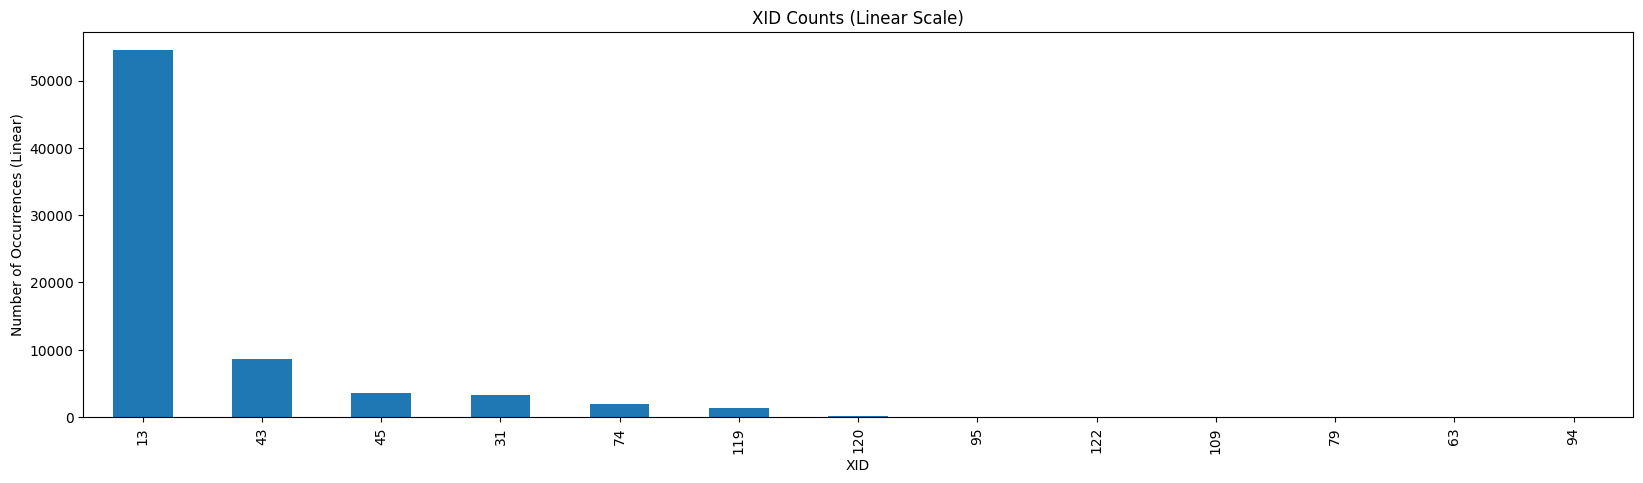

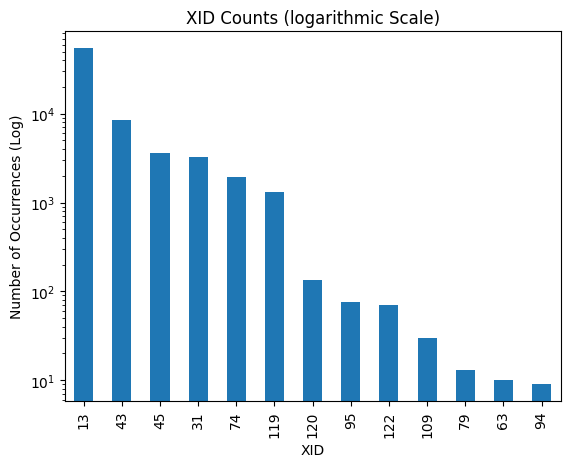

In [7]:
# first sort all XID's by the amount of times they appear
sorted_xid = dataframe['XID'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(20, 5))

# linear scale
sorted_xid.plot(kind='bar')
plt.title('XID Counts (Linear Scale)')
plt.xlabel('XID')
plt.ylabel('Number of Occurrences (Linear)')
plt.show()

# logarithmic scale
sorted_xid.plot(kind='bar')
plt.yscale('log')
plt.title('XID Counts (logarithmic Scale)')
plt.xlabel('XID')
plt.ylabel('Number of Occurrences (Log)')
plt.show()

In [8]:
dominant = sorted_xid.head(1)
print("Most Dominant XID Error")
display(dominant)
# 1.4a

top_5 = sorted_xid.head(5)
print("\nTop 5 XID Errors")
display(top_5)
# 1.4b

print("According to Table 1 in the study, the fifth most frequent error is XID 74, "
      "which is categorized as an interconnect error. Its tag is NVLink Error, "
      "described as a connection issue between GPUs via the NVLink interconnection.")
# 1.4c

Most Dominant XID Error


XID
13    54478
Name: count, dtype: int64


Top 5 XID Errors


XID
13    54478
43     8592
45     3602
31     3272
74     1922
Name: count, dtype: int64

According to Table 1 in the study, the fifth most frequent error is XID 74, which is categorized as an interconnect error. Its tag is NVLink Error, described as a connection issue between GPUs via the NVLink interconnection.


In [9]:
interarrival_times = dataframe['Timestamp'].diff()

plt.figure(figsize=(10, 6))
plt.hist(interarrival_times, bins=250, color='orange', edgecolor='black')
plt.title('Histogram of XID Interarrival Times (Entire System)')
plt.xlabel('Interarrival Time (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
# 1.5a

mean = interarrival_times.mean()
standard_dev = interarrival_times.std()
print("Mean: ", mean)
print("Standard Deviation: ", standard_dev)
# 1.5b

print("On average, a job can run for", mean, "seconds before an interruption.")
# 1.5c

KeyboardInterrupt: 

In [ ]:
#Want to use the Goodness of Fit Function from Scipy in order to test what distribution the 
#Interarrival Times of the XID are. 
from scipy import stats

# print("Test")

interarrival_times = interarrival_times.dropna() # Want to remove NAN values from interarrival times

# A: Exponential Distribution 
results_exponential = stats.goodness_of_fit(stats.expon, interarrival_times, statistic='ks', n_mc_samples=1000)
print("The p value for the exponential tests is ", results_exponential.pvalue)
print("The statistics for the exponential test is ", results_exponential.statistic)
print("The fitted paramters for exponential are ", results_exponential.fit_result.params)

#B: Normal Distribution 
results_normal = stats.goodness_of_fit(stats.norm, interarrival_times, statistic='ks', n_mc_samples=1000)
print("The p value for the normal tests is ", results_normal.pvalue)
print("The statistics for the normal test is ", results_normal.statistic)
print("The fitted paramters for normal are ", results_normal.fit_result.params)

#C: Uniform Distribution 
results_uniform = stats.goodness_of_fit(stats.uniform, interarrival_times, statistic='ks', n_mc_samples=1000)
print("The p value for the uniform tests is ", results_uniform.pvalue)
print("The statistics for the uniform test is ", results_uniform.statistic)
print("The fitted paramters for uniform are ", results_uniform.fit_result.params)

#D: Lognormal Distribution
results_logNormal = stats.goodness_of_fit(stats.lognorm, interarrival_times, known_params={'loc': 0}, statistic='ks', n_mc_samples=1000)
print("The p value for the lognormal tests is ", results_logNormal.pvalue)
print("The statistics for the lognormal test is ", results_logNormal.statistic)
print("The fitted paramters for lognormal are ", results_logNormal.fit_result.params)


The p value for the exponential tests is  0.4245754245754246
The statistics for the exponential test is  0.0027587078476604687
The fitted paramters for exponential are  FitParams(loc=np.float64(0.011411905288696289), scale=np.float64(1054.4761089655117))
The p value for the normal tests is  0.000999000999000999
The statistics for the normal test is  0.160304403757268
The fitted paramters for normal are  FitParams(loc=np.float64(1054.4875208708004), scale=np.float64(1061.687541810317))
The p value for the uniform tests is  0.000999000999000999
The statistics for the uniform test is  0.7107835116555101
The fitted paramters for uniform are  FitParams(loc=np.float64(0.011411905288696289), scale=np.float64(12756.949822425842))
The p value for the lognormal tests is  0.000999000999000999
The statistics for the lognormal test is  0.07109998037689785
The fitted paramters for lognormal are  FitParams(s=np.float64(1.282634637321251), loc=np.float64(0.0), scale=np.float64(590.9893987294186))



## Results from Distribution Test

As we can see from the above tests, the distributions which produce a  p value less than 0.05 are normal, uniform, and loganormal wheras the exponential distribution produces the highest p value. As a result, the best fit distribution is the exponential disribution. Given the scale parameter, we can 
find the corresponding lambda

## Part 1 Question 7 

1) Given that the probability distribution of the interarrival times is exponentials, the probability distribution that measures the number of arrivals in a time interval should be Poisson. 

2) The parameters are lambda, which is the average number of arrivals for the time interval, and k which is the number of arrivals. In this case, our lambda is 1/scale, which is 1/1054.48. 

3) For the model to work as expected, we would need for CDF(5) to be at least 0.8. This equates to the probability of 5 arrivals minus the probability of 0 arrivals. Since the time interval is 1 hour, we multiply by 3600 to get the time interval. As such, our Lambda is 3600 * (1/scale). Computing this gives us a Lambda of ~ 3.414. Using poisson distribution CDF, we have P(x<=5) ~ 0.863, which passes the 80 percent threshold set by the SLO requirement. As such, the system meets the users requirements.

## Part 2 Question 1

1) The interarrival times distribution is exponential distribution, with parameter lambda being equal to 1/1054.48. Our answer agrees with the TA, because we found that the distribution should be exponential. 

In [ ]:
# Part 2 Question 3 requires finding the number of operational hours, over the the number of 
# failure events

#Each XID is considered a failure event, find length of XIDs in panda dataframe
#Find number of days, multiply by 24 hours 
#We find the number of days by taking length of the 

xid_length = dataframe['XID'].count()
num_of_hours = len(dataframe['Date'].unique()) * 24

#Divide to obtain MTTF
mtbf = num_of_hours/xid_length # dividing by total amount of hours vs the xid_length
print("The MTBF in hours is ", mtbf)

#Obtain in terms of seconds 
# this is an empirical conversion by multplying by 3600 to get it in terms of seconds, as it is 3600 seconds / 1 hours
mtbf_seconds = mtbf * 3600

print("The MTBF in seconds is ", mtbf_seconds)





The MTBF in hours is  0.29316864814865196
The MTBF in seconds is  1055.4071333351471


In [ ]:
#Part 2 question 4 is finding the expected value of the mean time failure using the lambda we derived 
# from earlier. We know that the expected value of an exponential distribution is 1/lambda 
#given that lambda is equal to 1/lambda 

lamb = 1/1054.48 # We set the lamb value to get 1/scale 

expected_value_exp = 1/lamb # expected value calculated as such

print("Distribution Mean Time Between Failures ", expected_value_exp)



Distribution Mean Time Between Failures  1054.48


## Part 2 Question 4 

1) As we can see from the MTBF in seconds calculated empirically is very close to the expected value given from the exponential distribution. Thus, the fitted parameter given for the exponential distribution is true to the empirical data. 

2) The relation we found is not enough to establish that exponential distribution is a good fit, because the MTBF is just one statistic which only captures the mean and not the shape of the distribution. Another statistic which we calculated is the KS statistic and the p value, which both showed good results that demonstrated that exponential distribution is a good fit for the data's distribution

In [ ]:
#Part 2 Question 5 

#a --> Sort the interarrival times, then find the unique interarrival value times

interarrival_times_clean = interarrival_times.dropna().values
unique_interarrival_times = np.sort(np.unique(interarrival_times_clean))
print(f"Number of unique interarrival time values: {len(unique_interarrival_times)}")
print(f"First 10 unique times: {unique_interarrival_times[:10]}")                                 

#b Want to create the nelson-Aalen estimator function as well as empty array to store values
H = np.zeros(len(interarrival_times_clean))
d_values = np.array([np.sum(interarrival_times_clean == t) for t in unique_interarrival_times])
n_values = np.array([np.sum(interarrival_times_clean >= t) for t in unique_interarrival_times])
cumsum_per_unique = np.cumsum(d_values / n_values)
for i, obs_time in enumerate(interarrival_times_clean):
    # Find which unique times are <= obs_time
    idx = np.searchsorted(unique_interarrival_times, obs_time, side='right') - 1
    H[i] = cumsum_per_unique[idx] if idx >= 0 else 0

print("\nFirst 10 values of H(t):")
print(H[:10])

#c Plot the estimated cumulative hazard function Ĥ(𝑡) versus the corresponding timestamps


Number of unique interarrival time values: 73512
First 10 unique times: [0.01141191 0.0275631  0.05462003 0.06886816 0.08463407 0.10743761
 0.11227942 0.12138295 0.12173295 0.1219275 ]

First 10 values of H(t):
[0.11506021 1.91353442 0.0616177  0.37756718 0.31959278 0.63821154
 2.41762241 4.01116291 0.0040346  0.39159492]
